# Computational Intelligence Project: Island Genetic Algorithm

This notebook demonstrates the incremental implementation of an advanced Genetic Algorithm (GA) to solve a variation of the Vehicle Routing Problem (VRP) with non-linear costs. 

## The Problem
We need to collect gold from $N$ cities and return it to a base (0). 
**Cost Function**: $c(d, w) = d + (\alpha \cdot d \cdot w)^\beta$

Where $\beta$ can be high (e.g., 5.0), making heavy loads extremely expensive over distance.

In [7]:
import logging
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict

# Import from our unified codebase
from problem import Problem
from src.solver import GA_Solver

logging.basicConfig(level=logging.INFO, format='%(message)s')

## 1. Problem Definition
We use the shared `Problem` class to generate the graph and calculate costs.

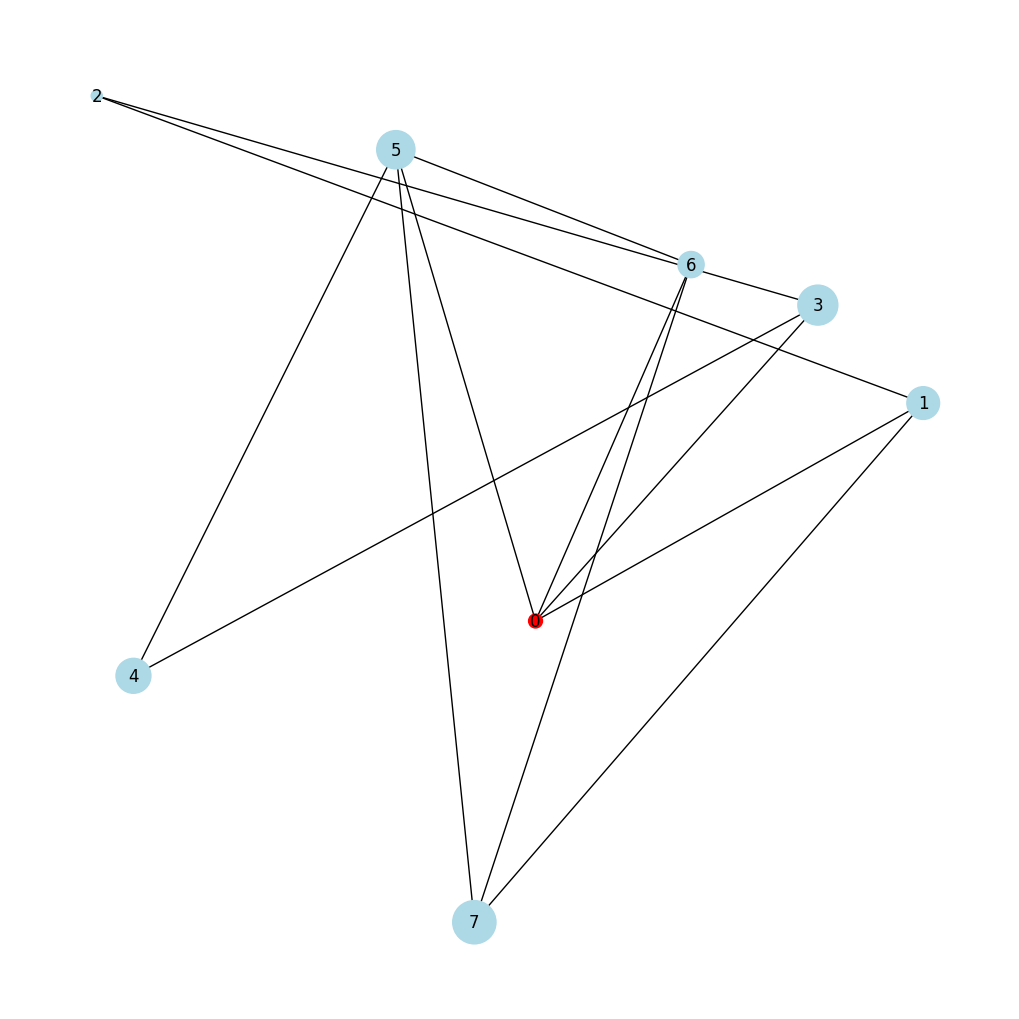

In [42]:
# Initialize Problem
problem = Problem(num_cities=8, alpha=1.0,beta=1.2,density=0.2, seed=42)
problem.plot()
plt.show()

## 2. Solution Strategy: Island GA + Virtual Nodes
We use the `GA_Solver` class which encapsulates:
1.  **Virtual Nodes**: Splitting heavy cities.
2.  **Island Model**: 4 distinct populations (Exploit, Balanced, Explore, Chaos).
3.  **Adaptive Parameters**: Evolving mutation rates and window sizes.

We will run the solver step-by-step.

In [43]:
# Initialize Solver
solver = GA_Solver(problem, pop_size_per_island=20)

print(f"Initial Best Cost: {solver.global_best.cost:.2e}")

Initial Best Cost: 6.63e+03


## 3. Running the Evolution
We can step through generations and observe the convergence.

In [44]:
generations = 200
history = {'gen': [], 'best_cost': []}

for g in range(generations):
    stats = solver.step_generation()
    
    history['gen'].append(stats['gen'])
    history['best_cost'].append(stats['best_cost'])
    
    if g % 10 == 0:
        print(f"Gen {g}: Best Cost {stats['best_cost']:.4e}")

Gen 0: Best Cost 6.5958e+03
Gen 10: Best Cost 6.5941e+03
Gen 20: Best Cost 6.5941e+03
Gen 30: Best Cost 6.5932e+03
Gen 40: Best Cost 6.5932e+03
Gen 50: Best Cost 6.5932e+03
Gen 60: Best Cost 6.5932e+03
Gen 70: Best Cost 6.5932e+03
Gen 80: Best Cost 6.5932e+03
Gen 90: Best Cost 6.5932e+03
Gen 100: Best Cost 6.5932e+03
Gen 110: Best Cost 6.5932e+03
Gen 120: Best Cost 6.5932e+03
Gen 130: Best Cost 6.5932e+03
Gen 140: Best Cost 6.5932e+03
Gen 150: Best Cost 6.5932e+03
Gen 160: Best Cost 6.5932e+03
Gen 170: Best Cost 6.5932e+03
Gen 180: Best Cost 6.5932e+03
Gen 190: Best Cost 6.5932e+03


In [48]:
best_ind = solver.global_best
formatted_solution = []
        
# best_ind.trips is a list of lists, e.g., [[v1, v2], [v3, v4]]
for trip in best_ind.trips:
    for v_node in trip:
            # Map virtual node ID back to real city ID
        real_node = solver.virtual_map[v_node]
            # distinct gold amount for this specific virtual chunk
        gold_amount = solver.node_golds[v_node]
                
        formatted_solution.append((real_node, gold_amount))
            
    # Append "Return to Base" (City 0, 0 Gold) after every trip
    formatted_solution.append((0, 0))

In [49]:
formatted_solution

[(4, 126.40654694458856),
 (5, 151.66593046905768),
 (0, 0),
 (4, 126.40654694458856),
 (5, 151.66593046905768),
 (0, 0),
 (3, 137.96725680343158),
 (0, 0),
 (3, 137.96725680343158),
 (0, 0),
 (3, 137.96725680343158),
 (0, 0),
 (3, 137.96725680343158),
 (0, 0),
 (2, 64.75343884807114),
 (0, 0),
 (3, 137.96725680343158),
 (0, 0),
 (1, 138.75755055720475),
 (0, 0),
 (7, 138.67533233864407),
 (0, 0),
 (7, 138.67533233864407),
 (6, 118.39048072057949),
 (0, 0),
 (4, 126.40654694458856),
 (5, 151.66593046905768),
 (0, 0),
 (7, 138.67533233864407),
 (0, 0),
 (7, 138.67533233864407),
 (0, 0),
 (7, 138.67533233864407),
 (6, 118.39048072057949),
 (0, 0),
 (7, 138.67533233864407),
 (6, 118.39048072057949),
 (0, 0),
 (7, 138.67533233864407),
 (0, 0),
 (4, 126.40654694458856),
 (5, 151.66593046905768),
 (0, 0),
 (1, 138.75755055720475),
 (0, 0),
 (3, 137.96725680343158),
 (0, 0),
 (4, 126.40654694458856),
 (5, 151.66593046905768),
 (0, 0),
 (1, 138.75755055720475),
 (0, 0),
 (1, 138.75755055720475

In [47]:
print(f"\nFinal Solution Cost: {solver.global_best.cost:.4e}")

print(f"Returned base {formatted_solution.count((0, 0))-1} times")


Final Solution Cost: 6.5932e+03
Returned base 22 times


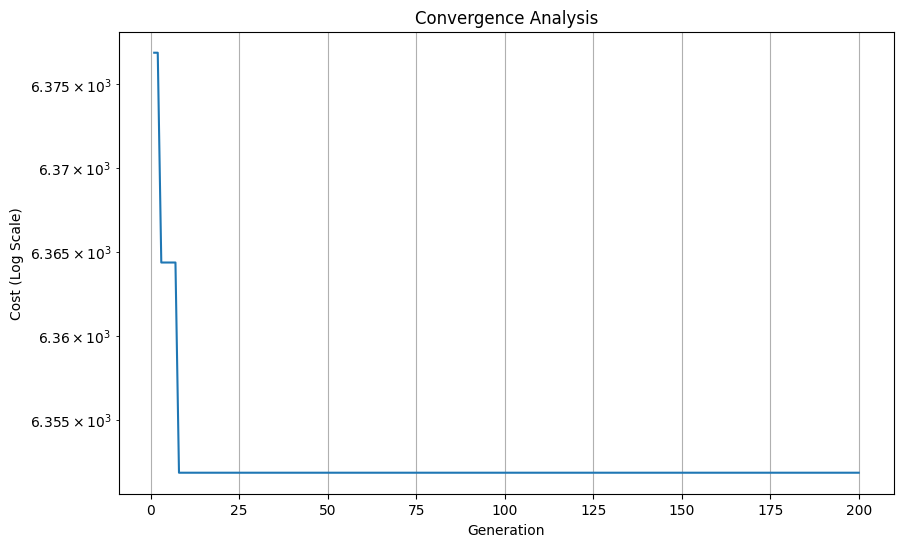

In [40]:
# Plot Convergence
plt.figure(figsize=(10, 6))
plt.plot(history['gen'], history['best_cost'])
plt.yscale('log')
plt.title('Convergence Analysis')
plt.xlabel('Generation')
plt.ylabel('Cost (Log Scale)')
plt.grid(True)
plt.show()

## 4. Comparison with Baseline
We compare our result against the simple Dijkstra baseline.

In [41]:
baseline_cost = problem.baseline()
print(f"Baseline Cost: {baseline_cost:.2e}")
print(f"My Solution Cost: {solver.global_best.cost:.2e}")

if solver.global_best.cost < baseline_cost:
    factor = baseline_cost / solver.global_best.cost
    print(f"Improvement Factor: {factor:.5f}x better")
else:
    print("No improvement.")

Baseline Cost: 7.77e+03
My Solution Cost: 6.35e+03
Improvement Factor: 1.22372x better
